In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from pandas.core.dtypes.common import is_numeric_dtype
import ast

In [2]:
customer_data = pd.read_csv('../data/task02/customer_data_collection.csv')
product_recommendation_data = pd.read_csv('../data/task02/product_recommendation_data.csv')

print(f'Customer Data shape:\n{customer_data.shape}')
print(f"Product Data shape:\n{product_recommendation_data.shape}")

display(customer_data.head())
display(product_recommendation_data.head())

Customer Data shape:
(10000, 11)
Product Data shape:
(10000, 15)


,Customer_ID,Age,Gender,Location,Browsing_History,Purchase_History,Customer_Segment,Avg_Order_Value,Holiday,Season,Unnamed: 10
0,C1000,28,Female,Chennai,"['Books', 'Fashion']","['Biography', 'Jeans']",New Visitor,4806.99,No,Winter,NaN
1,C1001,27,Male,Delhi,"['Books', 'Fitness', 'Fashion']","['Biography', 'Resistance Bands', 'T-shirt']",Occasional Shopper,795.03,Yes,Autumn,NaN
2,C1002,34,Other,Chennai,['Electronics'],['Smartphone'],Occasional Shopper,1742.45,Yes,Summer,NaN
3,C1003,23,Male,Bangalore,['Home Decor'],['Wall Art'],Frequent Buyer,2023.16,No,Autumn,NaN
4,C1004,24,Other,Kolkata,"['Fashion', 'Home Decor']","['Shoes', 'Lamp']",Frequent Buyer,794.76,No,Winter,NaN


,Product_ID,Category,Subcategory,Price,Brand,Average_Rating_of_Similar_Products,Product_Rating,Customer_Review_Sentiment_Score,Holiday,Season,Geographical_Location,Similar_Product_List,Probability_of_Recommendation,Unnamed: 13,Unnamed: 14
0,P2000,Fashion,Jeans,1713,Brand B,4.2,2.3,0.26,No,Summer,Canada,"['Jeans', 'Shoes']",0.91,NaN,NaN
1,P2001,Beauty,Lipstick,1232,Brand C,4.7,2.1,0.21,Yes,Winter,India,"['Moisturizer', 'Lipstick', 'Lipstick']",0.26,NaN,NaN
2,P2002,Electronics,Laptop,4833,Brand B,3.5,2.4,0.74,Yes,Spring,Canada,"['Headphones', 'Headphones', 'Smartphone']",0.60,NaN,NaN
3,P2003,Books,Comics,4902,Brand D,3.4,4.2,0.80,No,Winter,Germany,"['Biography', 'Non-fiction', 'Comics']",0.36,NaN,NaN
4,P2004,Home Decor,Cushions,856,Brand C,3.2,3.3,0.08,Yes,Summer,USA,['Lamp'],0.37,NaN,NaN


In [3]:
def remove_unnamed_columns(df):
    return df.loc[:, ~df.columns.str.contains('^Unnamed')]

def view_shape(df, name):
    return f'{name} shape:\n{df.shape}'

customer_data = remove_unnamed_columns(customer_data)
product_recommendation_data = remove_unnamed_columns(product_recommendation_data)

print(view_shape(customer_data, 'Customer Data'))
print(view_shape(product_recommendation_data, 'Product Recommendation Data'))


Customer Data shape:
(10000, 10)
Product Recommendation Data shape:
(10000, 13)


In [4]:
print(customer_data.head())
print(customer_data.info())

  Customer_ID  Age  Gender   Location                 Browsing_History  \
0       C1000   28  Female    Chennai             ['Books', 'Fashion']   
1       C1001   27    Male      Delhi  ['Books', 'Fitness', 'Fashion']   
2       C1002   34   Other    Chennai                  ['Electronics']   
3       C1003   23    Male  Bangalore                   ['Home Decor']   
4       C1004   24   Other    Kolkata        ['Fashion', 'Home Decor']   

                               Purchase_History    Customer_Segment  \
0                        ['Biography', 'Jeans']         New Visitor   
1  ['Biography', 'Resistance Bands', 'T-shirt']  Occasional Shopper   
2                                ['Smartphone']  Occasional Shopper   
3                                  ['Wall Art']      Frequent Buyer   
4                             ['Shoes', 'Lamp']      Frequent Buyer   

   Avg_Order_Value Holiday  Season  
0          4806.99      No  Winter  
1           795.03     Yes  Autumn  
2          1742.4

In [5]:
print(product_recommendation_data.head())
print(product_recommendation_data.info())

  Product_ID     Category Subcategory  Price    Brand  \
0      P2000      Fashion       Jeans   1713  Brand B   
1      P2001       Beauty    Lipstick   1232  Brand C   
2      P2002  Electronics      Laptop   4833  Brand B   
3      P2003        Books      Comics   4902  Brand D   
4      P2004   Home Decor    Cushions    856  Brand C   

   Average_Rating_of_Similar_Products  Product_Rating  \
0                                 4.2             2.3   
1                                 4.7             2.1   
2                                 3.5             2.4   
3                                 3.4             4.2   
4                                 3.2             3.3   

   Customer_Review_Sentiment_Score Holiday  Season Geographical_Location  \
0                             0.26      No  Summer                Canada   
1                             0.21     Yes  Winter                 India   
2                             0.74     Yes  Spring                Canada   
3         

In [6]:
# Price column from int to float
product_recommendation_data['Price'] = product_recommendation_data['Price'].astype(float)

print(product_recommendation_data.head())


  Product_ID     Category Subcategory   Price    Brand  \
0      P2000      Fashion       Jeans  1713.0  Brand B   
1      P2001       Beauty    Lipstick  1232.0  Brand C   
2      P2002  Electronics      Laptop  4833.0  Brand B   
3      P2003        Books      Comics  4902.0  Brand D   
4      P2004   Home Decor    Cushions   856.0  Brand C   

   Average_Rating_of_Similar_Products  Product_Rating  \
0                                 4.2             2.3   
1                                 4.7             2.1   
2                                 3.5             2.4   
3                                 3.4             4.2   
4                                 3.2             3.3   

   Customer_Review_Sentiment_Score Holiday  Season Geographical_Location  \
0                             0.26      No  Summer                Canada   
1                             0.21     Yes  Winter                 India   
2                             0.74     Yes  Spring                Canada   
3   

In [7]:
# Turn headers into snake case

def headers_to_snake_case(df):
    df = df.copy()

    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip('_')
    )
    return df

customer_data = headers_to_snake_case(customer_data)
product_recommendation_data = headers_to_snake_case(product_recommendation_data)

print(customer_data.columns)
print(product_recommendation_data.columns)


Index(['customer_id', 'age', 'gender', 'location', 'browsing_history',
       'purchase_history', 'customer_segment', 'avg_order_value', 'holiday',
       'season'],
      dtype='str')
Index(['product_id', 'category', 'subcategory', 'price', 'brand',
       'average_rating_of_similar_products', 'product_rating',
       'customer_review_sentiment_score', 'holiday', 'season',
       'geographical_location', 'similar_product_list',
       'probability_of_recommendation'],
      dtype='str')


In [8]:
# Check for missing values

def check_missing_values(df, name):
    return f'Missing values in {name}:\n{df.isna().sum()}\n'

print(check_missing_values(customer_data, 'Customer Data'))
print(check_missing_values(product_recommendation_data, 'Product Recommendation Data'))



Missing values in Customer Data:
customer_id         0
age                 0
gender              0
location            0
browsing_history    0
purchase_history    0
customer_segment    0
avg_order_value     0
holiday             0
season              0
dtype: int64

Missing values in Product Recommendation Data:
product_id                            0
category                              0
subcategory                           0
price                                 0
brand                                 0
average_rating_of_similar_products    0
product_rating                        0
customer_review_sentiment_score       0
holiday                               0
season                                0
geographical_location                 0
similar_product_list                  0
probability_of_recommendation         0
dtype: int64



In [9]:
# Check for duplicate rows

def check_duplicate_rows(df):
    if df.duplicated().sum() > 0:
        return df[df.duplicated(keep=False)]

    return 'No duplicate rows found!'

print(check_duplicate_rows(customer_data))
print(check_duplicate_rows(product_recommendation_data))

No duplicate rows found!
No duplicate rows found!


In [10]:
# Check Invalid Values

def check_values_below_zero(df):

    for col_name in df.columns:
        if is_numeric_dtype(df[col_name]):
            invalid_value = df.loc[
                (df[col_name] < 0) |
                (df[col_name].isna())
            ]
            print(f'Below zero values in "{col_name}": {len(invalid_value)}')

    return f'All Columns checked'


def check_ratings(df, col_name):
    invalid_values = df.loc[
        (df[col_name] < 0) |
        (df[col_name] > 5) |
        (df[col_name].isna())
    ]

    if not invalid_values.empty:
        return f'Invalid ratings in "{col_name}": {len(invalid_values)}'

    return 'No invalid ratings found!'


invalid_product_recommendation_data = product_recommendation_data.loc[
    (product_recommendation_data['probability_of_recommendation'] < 0) |
    (product_recommendation_data['probability_of_recommendation'] > 1) |
    (product_recommendation_data['probability_of_recommendation'].isna())
]

print(f"Invalid products recommendation data: {len(invalid_product_recommendation_data)}")



print(check_values_below_zero(customer_data))
print(check_values_below_zero(product_recommendation_data))

print(check_ratings(product_recommendation_data, 'average_rating_of_similar_products'))
print(check_ratings(product_recommendation_data, 'product_rating'))



Invalid products recommendation data: 0
Below zero values in "age": 0
Below zero values in "avg_order_value": 0
All Columns checked
Below zero values in "price": 0
Below zero values in "average_rating_of_similar_products": 0
Below zero values in "product_rating": 0
Below zero values in "customer_review_sentiment_score": 0
Below zero values in "probability_of_recommendation": 0
All Columns checked
No invalid ratings found!
No invalid ratings found!


In [11]:
print(product_recommendation_data.head())

  product_id     category subcategory   price    brand  \
0      P2000      Fashion       Jeans  1713.0  Brand B   
1      P2001       Beauty    Lipstick  1232.0  Brand C   
2      P2002  Electronics      Laptop  4833.0  Brand B   
3      P2003        Books      Comics  4902.0  Brand D   
4      P2004   Home Decor    Cushions   856.0  Brand C   

   average_rating_of_similar_products  product_rating  \
0                                 4.2             2.3   
1                                 4.7             2.1   
2                                 3.5             2.4   
3                                 3.4             4.2   
4                                 3.2             3.3   

   customer_review_sentiment_score holiday  season geographical_location  \
0                             0.26      No  Summer                Canada   
1                             0.21     Yes  Winter                 India   
2                             0.74     Yes  Spring                Canada   
3   

In [12]:
print(customer_data.head())


  customer_id  age  gender   location                 browsing_history  \
0       C1000   28  Female    Chennai             ['Books', 'Fashion']   
1       C1001   27    Male      Delhi  ['Books', 'Fitness', 'Fashion']   
2       C1002   34   Other    Chennai                  ['Electronics']   
3       C1003   23    Male  Bangalore                   ['Home Decor']   
4       C1004   24   Other    Kolkata        ['Fashion', 'Home Decor']   

                               purchase_history    customer_segment  \
0                        ['Biography', 'Jeans']         New Visitor   
1  ['Biography', 'Resistance Bands', 'T-shirt']  Occasional Shopper   
2                                ['Smartphone']  Occasional Shopper   
3                                  ['Wall Art']      Frequent Buyer   
4                             ['Shoes', 'Lamp']      Frequent Buyer   

   avg_order_value holiday  season  
0          4806.99      No  Winter  
1           795.03     Yes  Autumn  
2          1742.4

In [13]:
# Normalize list looking values to joined string values

def normalize_list_to_string(value):
    try:
         value_as_list = ast.literal_eval(value)
         if isinstance(value_as_list, list):
             values_lower = [
                 str(val).strip().lower() for val in value_as_list
             ]

             return ', '.join(values_lower)
    except (ValueError, SyntaxError):
        pass

    return value


def normalize_cols(df, cols):
    for col in cols:
        df[col] = df[col].apply(normalize_list_to_string)

    return df


normalize_cols(customer_data, ['browsing_history', 'purchase_history'])
normalize_cols(product_recommendation_data, ['similar_product_list'])

print(customer_data.head())
print('\n ------------------------------\n')
print(product_recommendation_data.head())


  customer_id  age  gender   location         browsing_history  \
0       C1000   28  Female    Chennai           books, fashion   
1       C1001   27    Male      Delhi  books, fitness, fashion   
2       C1002   34   Other    Chennai              electronics   
3       C1003   23    Male  Bangalore               home decor   
4       C1004   24   Other    Kolkata      fashion, home decor   

                       purchase_history    customer_segment  avg_order_value  \
0                      biography, jeans         New Visitor          4806.99   
1  biography, resistance bands, t-shirt  Occasional Shopper           795.03   
2                            smartphone  Occasional Shopper          1742.45   
3                              wall art      Frequent Buyer          2023.16   
4                           shoes, lamp      Frequent Buyer           794.76   

  holiday  season  
0      No  Winter  
1     Yes  Autumn  
2     Yes  Summer  
3      No  Autumn  
4      No  Winter  

 

In [14]:
product_recommendation_data.isna().sum()

product_id                            0
category                              0
subcategory                           0
price                                 0
brand                                 0
average_rating_of_similar_products    0
product_rating                        0
customer_review_sentiment_score       0
holiday                               0
season                                0
geographical_location                 0
similar_product_list                  0
probability_of_recommendation         0
dtype: int64

In [15]:
customer_data.isna().sum()

customer_id         0
age                 0
gender              0
location            0
browsing_history    0
purchase_history    0
customer_segment    0
avg_order_value     0
holiday             0
season              0
dtype: int64

In [23]:
# Customer count per segment

customer_per_segment = (
    customer_data
    .groupby('customer_segment')
    .agg(customer_count=('customer_id', 'count'))
    .reset_index()
    .sort_values('customer_count', ascending=False)
)
customer_per_segment.head()

,customer_segment,customer_count
2,Occasional Shopper,3378
0,Frequent Buyer,3325
1,New Visitor,3297


In [28]:
# Average order per customer segment

avg_order_per_segment = (
    customer_data
    .groupby('customer_segment')
    .agg(avg_order=('avg_order_value','mean'))
    .reset_index()
    .sort_values('avg_order', ascending=False)
)

avg_order_per_segment.head()

,customer_segment,avg_order
1,New Visitor,2761.685569
2,Occasional Shopper,2754.719366
0,Frequent Buyer,2739.747365


**New Visitor** segment has the highest average order value

In [33]:
# Average order value per location

# avg_order_per_location = (
#     customer_data
#     .groupby('location')
#     .agg(avg_order=('avg_order_value','mean'))
#     .reset_index()
#     .sort_values('avg_order', ascending=False)
# )


# Using the .mean() method
avg_order_per_location = (
    customer_data
    .groupby('location')['avg_order_value']
    .mean()
    .reset_index(name='avg_order')
    .sort_values('avg_order', ascending=False)
)

avg_order_per_location.head()


,location,avg_order
4,Mumbai,2766.813008
0,Bangalore,2766.078034
1,Chennai,2754.598471
2,Delhi,2749.431404
3,Kolkata,2724.507859


**Mumbai** has the highest aveerage order value

In [34]:
# Customer count per gender

customer_count_per_gender = (
    customer_data
    .groupby('gender')['customer_id']
    .count()
    .reset_index(name='customer_count')
    .sort_values('customer_count', ascending=False)
)

customer_count_per_gender.head()

,gender,customer_count
2,Other,3471
0,Female,3301
1,Male,3228


In [39]:
# Customer count by season and holiday

customer_count_per_season_holiday = (
    customer_data
    .groupby(['season', 'holiday'])['customer_id']
    .count()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

customer_count_per_season_holiday

,season,holiday,count
1,Autumn,Yes,1311
0,Autumn,No,1287
7,Winter,Yes,1268
2,Spring,No,1256
4,Summer,No,1251
6,Winter,No,1223
5,Summer,Yes,1212
3,Spring,Yes,1192


**Autumn** has the highest-value customers

In [40]:
customer_data.head()

,customer_id,age,gender,location,browsing_history,purchase_history,customer_segment,avg_order_value,holiday,season
0,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter
1,C1001,27,Male,Delhi,"books, fitness, fashion","biography, resistance bands, t-shirt",Occasional Shopper,795.03,Yes,Autumn
2,C1002,34,Other,Chennai,electronics,smartphone,Occasional Shopper,1742.45,Yes,Summer
3,C1003,23,Male,Bangalore,home decor,wall art,Frequent Buyer,2023.16,No,Autumn
4,C1004,24,Other,Kolkata,"fashion, home decor","shoes, lamp",Frequent Buyer,794.76,No,Winter


In [42]:
product_recommendation_data.head()

,product_id,category,subcategory,price,brand,average_rating_of_similar_products,product_rating,customer_review_sentiment_score,holiday,season,geographical_location,similar_product_list,probability_of_recommendation
0,P2000,Fashion,Jeans,1713.0,Brand B,4.2,2.3,0.26,No,Summer,Canada,"jeans, shoes",0.91
1,P2001,Beauty,Lipstick,1232.0,Brand C,4.7,2.1,0.21,Yes,Winter,India,"moisturizer, lipstick, lipstick",0.26
2,P2002,Electronics,Laptop,4833.0,Brand B,3.5,2.4,0.74,Yes,Spring,Canada,"headphones, headphones, smartphone",0.60
3,P2003,Books,Comics,4902.0,Brand D,3.4,4.2,0.80,No,Winter,Germany,"biography, non-fiction, comics",0.36
4,P2004,Home Decor,Cushions,856.0,Brand C,3.2,3.3,0.08,Yes,Summer,USA,lamp,0.37


In [43]:
# Average product price per category

avg_price_per_category = (
    product_recommendation_data
    .groupby('category')['price']
    .mean()
    .reset_index(name='avg_price')
    .sort_values('avg_price', ascending=False)
)

avg_price_per_category.head()

,category,avg_price
3,Fashion,2618.472222
4,Fitness,2577.908268
5,Home Decor,2548.604748
2,Electronics,2548.096734
1,Books,2523.641671


In [44]:
# Avg product rating per category

rating_per_category = (
    product_recommendation_data
    .groupby('category')['product_rating']
    .mean()
    .reset_index(name='rating')
    .sort_values('rating', ascending=False)
)

rating_per_category.head()

,category,rating
2,Electronics,3.539433
0,Beauty,3.531894
1,Books,3.499370
4,Fitness,3.495896
3,Fashion,3.482407


In [45]:
product_recommendation_data.columns

Index(['product_id', 'category', 'subcategory', 'price', 'brand',
       'average_rating_of_similar_products', 'product_rating',
       'customer_review_sentiment_score', 'holiday', 'season',
       'geographical_location', 'similar_product_list',
       'probability_of_recommendation'],
      dtype='str')

In [46]:
# Average recommendation probability per brand

avg_recommendation_per_brand = (
    product_recommendation_data
    .groupby('brand')['probability_of_recommendation']
    .mean()
    .reset_index(name='avg_probability')
    .sort_values('avg_probability', ascending=False)
)

avg_recommendation_per_brand.head()

,brand,avg_probability
3,Brand D,0.556545
2,Brand C,0.552922
0,Brand A,0.549854
1,Brand B,0.545245


**Brand D** has the highest recommendation probability

In [47]:
# Avg sentiment score

avg_sentiment = (
    product_recommendation_data
    .groupby('brand')['customer_review_sentiment_score']
    .mean()
    .reset_index(name='avg_sentiment')
    .sort_values('avg_sentiment', ascending=False)
)

avg_sentiment.head()

,brand,avg_sentiment
3,Brand D,0.501514
2,Brand C,0.499611
0,Brand A,0.497693
1,Brand B,0.495706


In [48]:
# Number of products per category

products_per_category = (
    product_recommendation_data
    .groupby('category')['product_id']
    .nunique()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

products_per_category.head()

,category,count
1,Books,1747
5,Home Decor,1685
0,Beauty,1668
4,Fitness,1657
2,Electronics,1623


In [50]:
# Highest avg rating per brand

top_brand_rating = (
    product_recommendation_data
    .groupby('brand')['product_rating']
    .mean()
    .reset_index(name='rating')
    .sort_values('rating', ascending=False)
)

top_brand_rating.head(1)

,brand,rating
2,Brand C,3.525324


In [59]:
# Highest avg price per category

category_avg_price = (
    product_recommendation_data
    .groupby('category')['price']
    .mean()
    .reset_index(name='avg_price')
    .sort_values('avg_price', ascending=False)
)

category_avg_price.head()

,category,avg_price
3,Fashion,2618.472222
4,Fitness,2577.908268
5,Home Decor,2548.604748
2,Electronics,2548.096734
1,Books,2523.641671


The category **Fashion** hast the highest average price

In [68]:
# Product recommendation score table by brand and category

prod_recommendation_by_score = (
    product_recommendation_data
    .groupby(['brand', 'category'])['probability_of_recommendation']
    .mean()
    .reset_index(name='avg_recommendation_score')
    .sort_values('avg_recommendation_score', ascending=False)
)

prod_recommendation_by_score.head(25)

,brand,category,avg_recommendation_score
13,Brand C,Books,0.568345
15,Brand C,Fashion,0.565968
12,Brand C,Beauty,0.565616
20,Brand D,Electronics,0.564149
22,Brand D,Fitness,0.562222
18,Brand D,Beauty,0.561784
1,Brand A,Books,0.559341
23,Brand D,Home Decor,0.558392
9,Brand B,Fashion,0.558296
3,Brand A,Fashion,0.557481


In [70]:
# Brand summary table

brand_summary_table = (
    product_recommendation_data
    .groupby(['brand', 'category'])
    .agg(
        avg_product_rating=('product_rating', 'mean'),
        avg_sentiment=('customer_review_sentiment_score', 'mean'),
        avg_recommendation_probability=('probability_of_recommendation', 'mean'),
        avg_price=('price', 'mean'),
        product_count=('product_id', 'nunique'),
    )
    .reset_index()
)

brand_summary_table.head()

,brand,category,avg_product_rating,avg_sentiment,avg_recommendation_probability,avg_price,product_count
0,Brand A,Beauty,3.502463,0.506453,0.538227,2428.081281,406
1,Brand A,Books,3.496235,0.510188,0.559341,2578.075294,425
2,Brand A,Electronics,3.527494,0.509976,0.540803,2568.866180,411
3,Brand A,Fashion,3.499252,0.480175,0.557481,2609.231920,401
4,Brand A,Fitness,3.503210,0.493259,0.554889,2624.103704,405


In [71]:
product_recommendation_data.head(

)

,product_id,category,subcategory,price,brand,average_rating_of_similar_products,product_rating,customer_review_sentiment_score,holiday,season,geographical_location,similar_product_list,probability_of_recommendation
0,P2000,Fashion,Jeans,1713.0,Brand B,4.2,2.3,0.26,No,Summer,Canada,"jeans, shoes",0.91
1,P2001,Beauty,Lipstick,1232.0,Brand C,4.7,2.1,0.21,Yes,Winter,India,"moisturizer, lipstick, lipstick",0.26
2,P2002,Electronics,Laptop,4833.0,Brand B,3.5,2.4,0.74,Yes,Spring,Canada,"headphones, headphones, smartphone",0.60
3,P2003,Books,Comics,4902.0,Brand D,3.4,4.2,0.80,No,Winter,Germany,"biography, non-fiction, comics",0.36
4,P2004,Home Decor,Cushions,856.0,Brand C,3.2,3.3,0.08,Yes,Summer,USA,lamp,0.37


In [75]:
# High potential table

avg_sentiment_score = product_recommendation_data['customer_review_sentiment_score'].mean()
avg_probability_of_recommendation = product_recommendation_data['probability_of_recommendation'].mean()

high_potential = product_recommendation_data.loc[
    (product_recommendation_data['product_rating'] >=  4) &
    (product_recommendation_data['customer_review_sentiment_score'] >= avg_sentiment_score) &
    (product_recommendation_data['probability_of_recommendation'] >= avg_probability_of_recommendation ),
    [
        "product_id",
        "brand",
        "category",
        "subcategory",
        "price",
        "product_rating",
        "customer_review_sentiment_score",
        "probability_of_recommendation",
        "season",
        "holiday",
        "geographical_location"
    ]
]

print(high_potential.shape)
print(high_potential.head())


(845, 11)
   product_id    brand     category subcategory   price  product_rating  \
18      P2018  Brand C   Home Decor    Cushions  3252.0             5.0   
26      P2026  Brand D  Electronics  Smartwatch  4626.0             4.7   
59      P2059  Brand B      Fashion       Jeans  4932.0             4.2   
81      P2081  Brand A        Books     Fiction  4909.0             4.8   
83      P2083  Brand B      Fashion      Jacket  1099.0             4.8   

    customer_review_sentiment_score  probability_of_recommendation  season  \
18                             0.77                           0.64  Autumn   
26                             0.62                           0.78  Summer   
59                             0.79                           0.99  Winter   
81                             0.93                           0.57  Spring   
83                             0.72                           0.57  Summer   

   holiday geographical_location  
18     Yes               Germany  


In [77]:
print(customer_data)


     customer_id  age  gender   location         browsing_history  \
0          C1000   28  Female    Chennai           books, fashion   
1          C1001   27    Male      Delhi  books, fitness, fashion   
2          C1002   34   Other    Chennai              electronics   
3          C1003   23    Male  Bangalore               home decor   
4          C1004   24   Other    Kolkata      fashion, home decor   
...          ...  ...     ...        ...                      ...   
9995      C10995   19   Other     Mumbai      home decor, fashion   
9996      C10996   34   Other      Delhi                   beauty   
9997      C10997   59   Other      Delhi      electronics, beauty   
9998      C10998   39   Other      Delhi           books, fitness   
9999      C10999   38    Male    Chennai              electronics   

                          purchase_history    customer_segment  \
0                         biography, jeans         New Visitor   
1     biography, resistance bands, t-sh

In [78]:
print(product_recommendation_data
      )

     product_id     category  subcategory   price    brand  \
0         P2000      Fashion        Jeans  1713.0  Brand B   
1         P2001       Beauty     Lipstick  1232.0  Brand C   
2         P2002  Electronics       Laptop  4833.0  Brand B   
3         P2003        Books       Comics  4902.0  Brand D   
4         P2004   Home Decor     Cushions   856.0  Brand C   
...         ...          ...          ...     ...      ...   
9995     P11995       Beauty      Perfume  3184.0  Brand C   
9996     P11996       Beauty  Moisturizer  4207.0  Brand D   
9997     P11997      Fitness    Dumbbells   961.0  Brand A   
9998     P11998   Home Decor         Lamp  4973.0  Brand D   
9999     P11999       Beauty     Lipstick   740.0  Brand B   

      average_rating_of_similar_products  product_rating  \
0                                    4.2             2.3   
1                                    4.7             2.1   
2                                    3.5             2.4   
3              

In [85]:
# Recommendation targeting table

recommendation_target_table = (
    customer_data
    .merge(
        product_recommendation_data,
        on=['holiday', 'season'],
        how='inner'
    )
)

recommendation_target_table['recommendation_type'] = recommendation_target_table['probability_of_recommendation'] .apply(
    lambda x: 'high-priority' if x >= 0.75 else 'standard'
)


print(recommendation_target_table.shape)

(12492820, 22)


In [87]:
recommendation_target_table.head(20)


,customer_id,age,gender,location,browsing_history,purchase_history,customer_segment,avg_order_value,holiday,season,...,subcategory,price,brand,average_rating_of_similar_products,product_rating,customer_review_sentiment_score,geographical_location,similar_product_list,probability_of_recommendation,recommendation_type
0,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter,...,Comics,4902.0,Brand D,3.4,4.2,0.80,Germany,"biography, non-fiction, comics",0.36,standard
1,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter,...,T-shirt,1451.0,Brand A,4.7,2.5,0.68,Canada,"t-shirt, shoes, jacket",0.70,standard
2,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter,...,Fiction,3954.0,Brand B,3.2,3.6,0.95,Germany,"fiction, non-fiction, comics",0.74,standard
3,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter,...,Biography,1677.0,Brand B,2.3,2.3,0.45,Germany,non-fiction,0.87,high-priority
4,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter,...,Resistance Bands,3564.0,Brand D,3.9,2.7,0.52,Germany,"yoga mat, treadmill",0.63,standard
5,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter,...,Non-fiction,133.0,Brand D,2.1,4.5,0.62,Germany,"fiction, biography, comics",0.15,standard
6,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter,...,Moisturizer,2470.0,Brand D,3.5,3.0,0.87,Canada,"moisturizer, lipstick, perfume",0.94,high-priority
7,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter,...,Wall Art,1642.0,Brand A,2.1,4.0,0.46,UK,curtains,0.96,high-priority
8,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter,...,Yoga Mat,3032.0,Brand B,2.2,4.7,0.12,USA,"treadmill, treadmill",0.67,standard
9,C1000,28,Female,Chennai,"books, fashion","biography, jeans",New Visitor,4806.99,No,Winter,...,Lipstick,4435.0,Brand B,2.7,3.8,0.80,Canada,moisturizer,0.35,standard


In [90]:
# Best Segment Summary

best_segment_summary = (
    recommendation_target_table
    .groupby(['brand', 'customer_segment'])
    .agg(
        avg_order_value=('avg_order_value', 'mean'),
        number_of_customers=('customer_id', 'nunique'),
        avg_recommendation_probability=('probability_of_recommendation', 'mean'),
        best_location=('location', lambda x: x.mode().iloc[0]),
        best_season=('season', lambda x: x.mode().iloc[0]),
    )
    .reset_index()

)

best_segment_summary.head()

,brand,customer_segment,avg_order_value,number_of_customers,avg_recommendation_probability,best_location,best_season
0,Brand A,Frequent Buyer,2740.128713,3325,0.549951,Kolkata,Autumn
1,Brand A,New Visitor,2763.194561,3297,0.550216,Delhi,Autumn
2,Brand A,Occasional Shopper,2754.668370,3378,0.549587,Kolkata,Spring
3,Brand B,Frequent Buyer,2738.360911,3325,0.545435,Kolkata,Spring
4,Brand B,New Visitor,2762.390805,3297,0.545395,Delhi,Autumn


In [91]:
best_segment_summary.shape


(12, 7)

In [93]:
# Final Brand Targeting

final_brand_targeting = (
    best_segment_summary
    .sort_values(['avg_order_value'], ascending=False)
    .groupby('brand')
    .head(1)
    .reset_index(drop=True)
)

final_brand_targeting.head()

,brand,customer_segment,avg_order_value,number_of_customers,avg_recommendation_probability,best_location,best_season
0,Brand A,New Visitor,2763.194561,3297,0.550216,Delhi,Autumn
1,Brand D,New Visitor,2762.560570,3297,0.556624,Delhi,Autumn
2,Brand B,New Visitor,2762.390805,3297,0.545395,Delhi,Autumn
3,Brand C,New Visitor,2760.839590,3297,0.552437,Delhi,Autumn


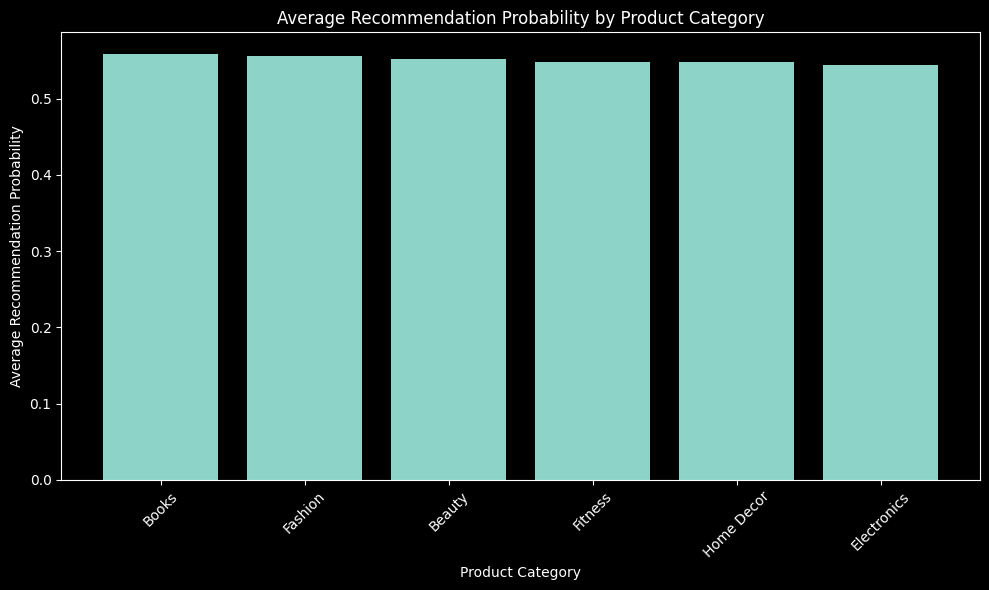

In [104]:
# Avg recommendation probability per category plot

avg_recommendation_per_category = (
    product_recommendation_data
    .groupby('category')['probability_of_recommendation']
    .mean()
    .reset_index(name='avg_recommendation_score')
    .sort_values('avg_recommendation_score', ascending=False)
)


plt.figure(figsize=(10, 6))
x = avg_recommendation_per_category['category']
y = avg_recommendation_per_category['avg_recommendation_score']

plt.bar(
    x,
    y,
)

plt.title("Average Recommendation Probability by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Recommendation Probability")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

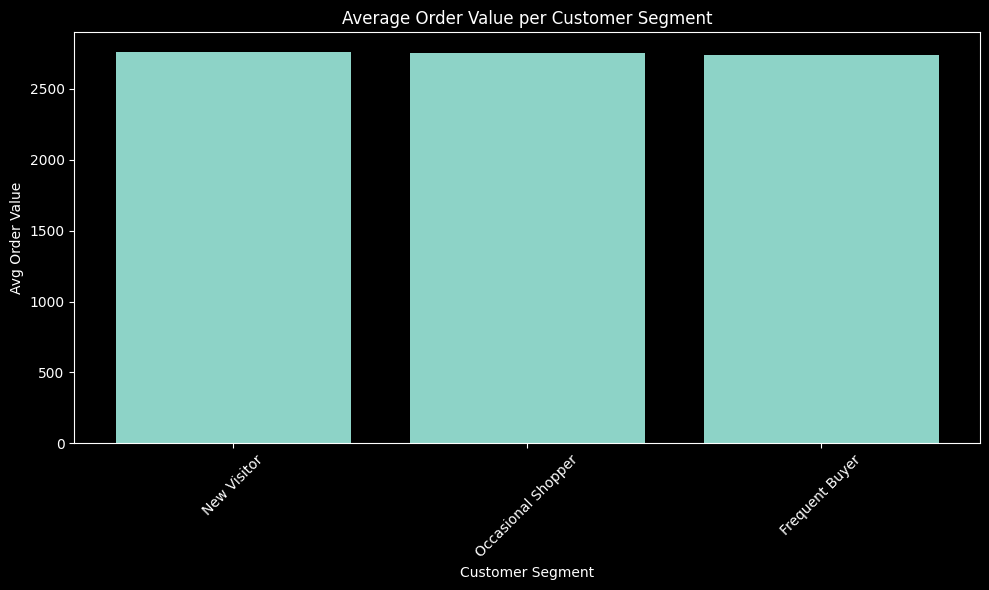

In [103]:
# Avg order value per customer segment plot

avg_order_per_segment.head()

x = avg_order_per_segment['customer_segment']
y = avg_order_per_segment['avg_order']

plt.figure(figsize=(10, 6))

plt.bar(
    x,
    y,
)

plt.title("Average Order Value per Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Avg Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [107]:
# Product rating vs recommendation probability box plot

product_recommendation_data["rating_group"] = pd.cut(
    product_recommendation_data["product_rating"],
    bins=[0, 2, 3, 4, 5],
    labels=["0-2", "2-3", "3-4", "4-5"]
)

/var/folders/h_/sh5w4t9j7wn57068g_t49qx40000gn/T/ipykernel_62205/229122092.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


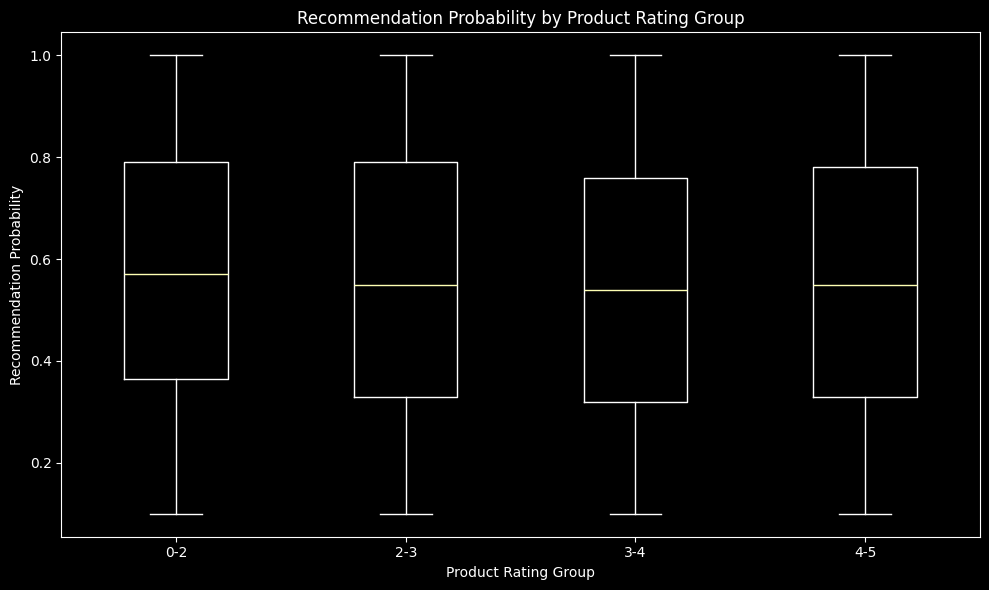

In [108]:
data_to_plot = [
    product_recommendation_data.loc[
        product_recommendation_data["rating_group"] == group,
        "probability_of_recommendation"
    ]
    for group in product_recommendation_data["rating_group"].cat.categories
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    data_to_plot,
    labels=product_recommendation_data["rating_group"].cat.categories
)

plt.title("Recommendation Probability by Product Rating Group")
plt.xlabel("Product Rating Group")
plt.ylabel("Recommendation Probability")
plt.tight_layout()

plt.show()